# SR Analysis — function tests

Each section below tests one function from `sr_analysis.py`.  

## 1. Setup

In [1]:
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "sr_analysis.py").exists())
sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols as sp_symbols

from sr_analysis import (
    parse_expression,
    classify_symbols,
    find_constant_recurrences,
    analyze_regimes,
    sensitivity_analysis,
    generate_report,
    generate_plain_language_prompt,
    # existing functions still available
    simplify_expression,
    variable_contributions,
    variable_interactions,
    complexity_report,
    behavioral_regimes,
)

## 2. Inputs 

In [2]:
# ── expression under test ──────────────────────────────────────────────────
EXPR = "((x_10 * x_7) / (x_14 + 0.1) + x_10**2 * x_14)"

# EXPR = "((x_10**3 * x_7) + (x_14 - x_7) + 1/(x_10 - 0.5))"

# Other expressions you can swap in:
# EXPR = "((x_10**3 * x_7) + (x_14 - x_7))"                     # no singularity
# EXPR = "((2.5 * x_10**2) + (2.5 / (x_14 + 2.5)) - x_7)"       # constant recurrence
# EXPR = "((x_10 * x_7) / (x_14 + 0.1) + x_10**2 * x_14)"       # multiple interactions
# EXPR = "Piecewise((x_10, x_7 > 0.5), (-x_10, True))"           # mixed boolean

# ── display names ──────────────────────────────────────────────────────────
VAR_MAP = {
    "x_0":  "pos",               "x_1":  "end",
    "x_2":  "aa_pos",            "x_3":  "phyloP17way_primate",
    "x_4":  "phastCons17way_primate", "x_5": "SiPhy_29way_logOdds",
    "x_6":  "GERP++_RS",         "x_7":  "MutationTaster_score",
    "x_8":  "LRT_score",         "x_9":  "FATHMM_score",
    "x_10": "MutPred_score",     "x_11": "SIFT_score",
    "x_12": "MutationAssessor_score", "x_13": "PROVEAN_score",
    "x_14": "VEST4_score",       "x_15": "Polyphen2_HDIV_score",
    "x_16": "Polyphen2_HVAR_score", "x_17": "log_AF_popmax",
    "x_18": "is_transition",     "x_19": "sub_code",
    "x_20": "blosum62",          "x_21": "delta_hydro",
    "x_22": "delta_volume",      "x_23": "delta_charge",
}

# ── data ranges ────────────────────────────────────────────────────────────
VAR_RANGES = {
    "x_0":  (1, 50000),    "x_1":  (1, 50000),    "x_2":  (1, 2000),
    "x_3":  (-3.0, 3.0),   "x_4":  (0.0, 1.0),    "x_5":  (0.0, 20.0),
    "x_6":  (-10.0, 10.0), "x_7":  (0.0, 1.0),    "x_8":  (0.0, 1.0),
    "x_9":  (-5.0, 5.0),   "x_10": (0.0, 1.0),    "x_11": (0.0, 1.0),
    "x_12": (0.0, 5.0),    "x_13": (-10.0, 5.0),  "x_14": (0.0, 1.0),
    "x_15": (0.0, 1.0),    "x_16": (0.0, 1.0),    "x_17": (-8.0, 0.0),
    "x_18": (0, 1),        "x_19": (0, 20),        "x_20": (-4, 11),
    "x_21": (-3.0, 3.0),   "x_22": (-200.0, 200.0), "x_23": (-2, 2),
}

## 3. `parse_expression`

The unified entry-point for any GP expression string

- parses the string with SymPy
- simplifies (keeping the shorter form)
- detects which variables are in arithmetic vs. boolean/condition roles
- lists branches only when a `Piecewise` is present 

In [3]:
parsed = parse_expression(EXPR, VAR_MAP)

print(f"Original            : {parsed['original']}")
print(f"Simplified (x_N)    : {parsed['simplified']}")
print(f"Simplified (named)  : {parsed['simplified_named']}")
print(f"Nodes before/after  : {parsed['node_count_before']} → {parsed['node_count_after']}")
print(f"Variables in expr   : {parsed['variables']}")
print(f"Numeric constants   : {parsed['constants']}")
print()
print(f"Is mixed (boolean)  : {parsed['is_mixed']}")
print(f"Boolean vars        : {parsed['boolean_vars'] or 'none'}")
print(f"Continuous vars     : {parsed['continuous_vars']}")
print(f"Dual-role vars      : {parsed['dual_role_vars'] or 'none'}")
print(f"Branches (Piecewise): {parsed['branches']}")

Original            : ((x_10 * x_7) / (x_14 + 0.1) + x_10**2 * x_14)
Simplified (x_N)    : x_10**2*x_14 + x_10*x_7/(x_14 + 0.1)
Simplified (named)  : MutPred_score**2*VEST4_score + MutPred_score*MutationTaster_score/(VEST4_score + 0.1)
Nodes before/after  : 14 → 14
Variables in expr   : ['x_10', 'x_14', 'x_7']
Numeric constants   : [0.1, -1.0, 2.0]

Is mixed (boolean)  : False
Boolean vars        : none
Continuous vars     : ['x_10', 'x_14', 'x_7']
Dual-role vars      : none
Branches (Piecewise): None


## 4. `classify_symbols`

Goes deeper than `parse_expression` on the variable side. For each free symbol it reports:

-  `role` -> `continuous` / `boolean` / `mixed` 
- `in_arithmetic` -> appears outside any condition 
- `in_relational` -> appears inside a comparison (`>`, `<`, …) 
- `occurrences` -> total node count in the tree 
- `display_name` -> human-readable name from `VAR_MAP` 

In [4]:
# A `mixed` variable is analytically tricky, it shifts between a numeric and a Boolean interpretation depending on context.
sym_cls = classify_symbols(parsed["expr"], VAR_MAP)

header = f"{'Symbol':<8}  {'Display name':<30}  {'Role':<12}  {'Arith':>5}  {'Rel':>5}  {'Count':>5}"
print(header)
print("-" * len(header))
for name, info in sym_cls.items():
    print(
        f"{name:<8}  {str(info['display_name']):<30}  {info['role']:<12}"
        f"  {str(info['in_arithmetic']):>5}  {str(info['in_relational']):>5}"
        f"  {info['occurrences']:>5}"
    )

Symbol    Display name                    Role          Arith    Rel  Count
---------------------------------------------------------------------------
x_10      MutPred_score                   continuous     True  False      2
x_14      VEST4_score                     continuous     True  False      2
x_7       MutationTaster_score            continuous     True  False      1


## 5. `find_constant_recurrences`

Walks the expression tree and counts every numeric literal
- Values 0, 1, and −1 are marked *trivial* (structural elements, not fitting artifacts).
- Any non-trivial constant that appears more than once is a **simplification candidate**: it could be factored or replaced by a shared sub-expression.
This is useful for spotting when the GP accidentally encoded the same fitting constant in multiple roles.

In [5]:
"""
cr = find_constant_recurrences(parsed["expr"])

print(f"Has non-trivial recurrences: {cr['has_recurrences']}")
print()
print(f"{'Value':>10}  {'Count':>5}  {'Trivial':>8}  {'Simplif. candidate':>20}")
print("-" * 50)
for c in cr["constants"]:
    print(
        f"{c['value']:>10.4g}  {c['count']:>5}  {str(c['is_trivial']):>8}"
        f"  {str(c['simplification_candidate']):>20}"
    )

if cr["recurrent"]:
    print()
    print("Recurrent non-trivial constants:")
    for r in cr["recurrent"]:
        print(f"  {r['value']} appears {r['count']} times → consider factoring")
"""

'\ncr = find_constant_recurrences(parsed["expr"])\n\nprint(f"Has non-trivial recurrences: {cr[\'has_recurrences\']}")\nprint()\nprint(f"{\'Value\':>10}  {\'Count\':>5}  {\'Trivial\':>8}  {\'Simplif. candidate\':>20}")\nprint("-" * 50)\nfor c in cr["constants"]:\n    print(\n        f"{c[\'value\']:>10.4g}  {c[\'count\']:>5}  {str(c[\'is_trivial\']):>8}"\n        f"  {str(c[\'simplification_candidate\']):>20}"\n    )\n\nif cr["recurrent"]:\n    print()\n    print("Recurrent non-trivial constants:")\n    for r in cr["recurrent"]:\n        print(f"  {r[\'value\']} appears {r[\'count\']} times → consider factoring")\n'

## 6. `analyze_regimes`

For each active variable (all others fixed at their data-range midpoint):

- **critical points**: zeros of the first derivative (local min/max)
- **inflection points**: zeros of the second derivative (curvature sign change)
- **singularities**: poles of the expression (denominator zero)
- **derivative** / **second derivative**: symbolic expressions
- **interpretation**: one deterministic sentence: *monotonic*, *has singularity at …*, or *has possible regime changes at …*

Everything is conditional on "others fixed at midpoint", so treat it as a local view around the median operating poin!!

In [6]:
# Build a Symbol-keyed ranges dict for only the variables actually in the expression
active_vars = {v: VAR_RANGES[v] for v in parsed["variables"] if v in VAR_RANGES}

reg = analyze_regimes(parsed["expr"], active_vars)

for var, info in reg["variables"].items():
    label = VAR_MAP.get(var, var)
    print(f"{var}  ({label})")
    print(f"  Derivative         : {info['derivative']}")
    print(f"  Second derivative  : {info['second_derivative']}")
    print(f"  Critical points    : {info['critical_points'] or 'none'}")
    print(f"  Inflection points  : {info['inflection_points'] or 'none'}")
    print(f"  Singularities      : {info['singularities'] or 'none'}")
    print(f"  → {info['interpretation']}")
    print()

x_10  (MutPred_score)
  Derivative         : 1.0*x_10 + 0.833333333333333
  Second derivative  : 1.00000000000000
  Critical points    : none
  Inflection points  : none
  Singularities      : none
  → monotonic over the inspected range

x_14  (VEST4_score)
  Derivative         : 0.25 - 0.25/(x_14 + 0.1)**2
  Second derivative  : 0.5/(x_14 + 0.1)**3
  Critical points    : [0.9]
  Inflection points  : none
  Singularities      : none
  → has possible regime changes at 0.9

x_7  (MutationTaster_score)
  Derivative         : 0.833333333333333
  Second derivative  : 0
  Critical points    : none
  Inflection points  : none
  Singularities      : none
  → monotonic over the inspected range



## 7. `sensitivity_analysis`

Pulls together three variable importance studies:

1. **Partial-effect ranking** sweep each variable over its full data range (50 pts), fix the others at their midpoint, rank by output swing. Big swing = high marginal importance.
2. **Interaction map** mixed partial ∂²f/∂xᵢ ∂xⱼ ≠ 0 means the two variables are structurally coupled (one changes the effect of the other).
3. **Derivative at midpoint** local slope of the expression with respect to each variable at the median operating point.

Warnings are raised automatically for any sweep that hits non-finite values (singularities, overflow).

In [7]:
sa = sensitivity_analysis(parsed["expr"], active_vars)

# --- ranking ---
print("Variable ranking (output range over full data range):")
finite = [(v, r) for v, r in sa["variable_ranking"] if np.isfinite(r)]
max_r  = max(r for _, r in finite) if finite else 1.0
for v, r in sa["variable_ranking"]:
    label = VAR_MAP.get(v, v)
    if np.isfinite(r):
        bar = "█" * int(r / max_r * 20)
        print(f"  {v:<6} {bar:<20}  {r:.4f}   ({label})")
    else:
        print(f"  {v:<6} {'(singularity in range)':<20}")

"""
# --- interactions ---
print()
if sa["interactions"]:
    print("Interacting pairs (∂²f/∂xi ∂xj ≠ 0):")
    for xi, xj, d2f in sa["interactions"]:
        print(f"  ({xi}, {xj})  mixed partial = {d2f}")
else:
    print("No interactions — all variables contribute independently.")
print(f"Independent: {sa['independent_vars'] or 'none'}")

# --- derivatives at midpoint ---
print()
print("First derivative at data-range midpoint:")
for v, info in sa["derivative_summaries"].items():
    val = info["value_at_midpoint"]
    val_str = f"{val:.4f}" if val is not None else "n/a"
    print(f"  ∂f/∂{v} = {info['symbolic_derivative']}   → {val_str} at midpoint")

# --- warnings ---
if sa["warnings"]:
    print()
    print("Warnings:")
    for w in sa["warnings"]:
        print(f"  ⚠ {w}")
"""

Variable ranking (output range over full data range):
  x_14   ████████████████████  2.0250   (VEST4_score)
  x_10   █████████████         1.3333   (MutPred_score)
  x_7    ████████              0.8333   (MutationTaster_score)


'\n# --- interactions ---\nprint()\nif sa["interactions"]:\n    print("Interacting pairs (∂²f/∂xi ∂xj ≠ 0):")\n    for xi, xj, d2f in sa["interactions"]:\n        print(f"  ({xi}, {xj})  mixed partial = {d2f}")\nelse:\n    print("No interactions — all variables contribute independently.")\nprint(f"Independent: {sa[\'independent_vars\'] or \'none\'}")\n\n# --- derivatives at midpoint ---\nprint()\nprint("First derivative at data-range midpoint:")\nfor v, info in sa["derivative_summaries"].items():\n    val = info["value_at_midpoint"]\n    val_str = f"{val:.4f}" if val is not None else "n/a"\n    print(f"  ∂f/∂{v} = {info[\'symbolic_derivative\']}   → {val_str} at midpoint")\n\n# --- warnings ---\nif sa["warnings"]:\n    print()\n    print("Warnings:")\n    for w in sa["warnings"]:\n        print(f"  ⚠ {w}")\n'

### Partial effect curves

One panel per active variable — the partial effect sweep used for the ranking above.

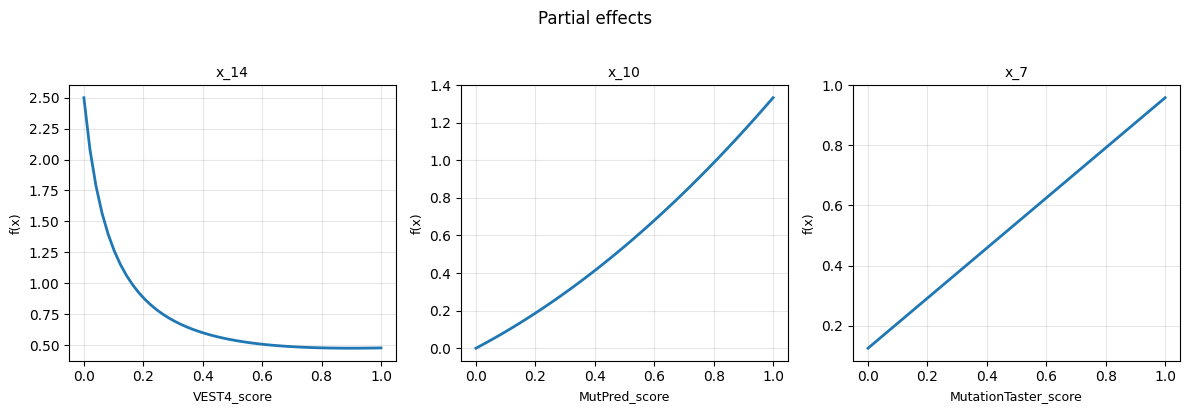

In [8]:
n = len(sa["variable_ranking"])
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
if n == 1:
    axes = [axes]

for ax, (v, _) in zip(axes, sa["variable_ranking"]):
    x_vals, y_vals = sa["partial_effects"][v]
    mask = np.isfinite(y_vals)
    label = VAR_MAP.get(v, v)
    ax.plot(x_vals[mask], y_vals[mask], linewidth=2)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("f(x)", fontsize=9)
    ax.set_title(v, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Partial effects", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 8. `generate_report`

The single entry-point for the full analysis pipeline

Pass an expression string, optional data ranges, and an optional display-name map; get back a structured report

`var_ranges` and `var_map` are optional. If ranges are omitted, `complexity`, `sensitivity`, and `regimes` are `None`.

In [13]:
report = generate_report(EXPR, var_ranges=active_vars, var_map=VAR_MAP)

# top-level keys
print("Report keys:", list(report.keys()))
print()

# warnings
if report["warnings"]:
    print("Warnings from the pipeline:")
    for w in report["warnings"]:
        print(f"  ⚠ {w}")
else:
    print("No warnings.")
print()

# complexity summary (subtree contributions)
if report["complexity"] and "error" not in report["complexity"]:
    comp = report["complexity"]
    print(f"Complexity — node count: {comp['node_count']}")
    print(f"{'Subtree':<35}  {'Contribution %':>14}")
    print("-" * 52)
    for s in comp["subtrees"]:
        flag = "  ← prune?" if s["contribution_pct"] < 5.0 else ""
        print(f"  {s['expr']:<33}  {s['contribution_pct']:>13.1f}%{flag}")

Report keys: ['parsed', 'symbol_classification', 'constants', 'complexity', 'sensitivity', 'regimes', 'warnings', 'facts_for_llm']

No warnings.

Complexity — node count: 14
Subtree                              Contribution %
----------------------------------------------------
  x_10*x_7/(x_14 + 0.1)                       92.1%
  x_10**2*x_14                                11.0%


## 9. `facts_for_llm` — what gets sent to an LLM

This is the curated subset of the report that is safe to pass to a language model  
It contains only values that were actually computed —> no free interpretation

The fields are:
- `expression`: original, simplified, named forms, node count, mixed flag
- `variables`: role, display name, occurrence count per variable
- `variable_ranking`: ordered list of (variable, output range) pairs
- `interactions`: variable pairs with nonzero mixed partial
- `independent_vars`: variables with no interactions
- `regimes`: per-variable interpretation strings and critical/singular points
- `warnings`: any computational warnings raised during analysis

In [10]:
import pprint
pprint.pprint(report["facts_for_llm"])

{'constants': {'non_trivial_values': [2.0, 0.1], 'recurrent_values': []},
 'critical_point_method': 'Fix all other variables at their data-range '
                          'midpoint; solve the first derivative equal to zero '
                          'analytically within the inspected range.',
 'expression': {'is_mixed_boolean_continuous': False,
                'node_count_after_simplification': 14,
                'original': '((x_10 * x_7) / (x_14 + 0.1) + x_10**2 * x_14)',
                'simplified': 'x_10**2*x_14 + x_10*x_7/(x_14 + 0.1)',
                'simplified_named': 'MutPred_score**2*VEST4_score + '
                                    'MutPred_score*MutationTaster_score/(VEST4_score '
                                    '+ 0.1)'},
 'input_ranges': {'x_10': [0.0, 1.0], 'x_14': [0.0, 1.0], 'x_7': [0.0, 1.0]},
 'monotonicity_method': 'Fix all other variables at their data-range midpoint; '
                        'verify that the first derivative has no real zeros '
     

## 10. `generate_plain_language_prompt`

Wraps `facts_for_llm` in a prompt that instructs a downstream LLM to:
1. explain only the verified facts (no extra knowledge),
2. not infer causality or domain meaning from variable names,
3. not mention variables absent from the facts,
4. qualify all behavioural claims with "over the inspected input ranges",
5. signal uncertainty explicitly.

This cell just prints the prompt.... no LLM call is made here.

In [14]:
prompt = generate_plain_language_prompt(report)
print(prompt)

You are a scientific writing assistant helping a researcher understand a symbolic regression expression produced by genetic programming.

STRICT RULES:
1. Explain only the facts listed in VERIFIED FACTS below. Do not add information absent from it.
2. Do not infer causality or domain meaning from variable names.
3. Do not mention any variable not present in the 'variables' section.
4. When describing behavior (monotone, bounded, singular), state explicitly that it holds only over the inspected input ranges.
5. If something is approximate or uncertain, say so explicitly.
6. Avoid phrases like 'this suggests', 'this implies', or 'therefore' unless directly traceable to a fact in VERIFIED FACTS.
7. Variable ranking is an output-range sensitivity estimate over the inspected input ranges. Do not call it causal importance, global importance, or relevance unless those words appear explicitly in VERIFIED FACTS.
8. When describing monotonicity, regime changes, or critical points, state that the